In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn import linear_model as lm

## **EPA AQS Data**

In [2]:
df_1 = pd.read_csv("../Data/LA_AQS_2023.csv")

print(df_1.shape)
print(df_1.head())

(22160, 34)
   State Code  County Code  Site Number  Parameter Code  POC  Latitude  \
0           6           37         1103           68103    1  34.06659   
1           6           37         1103           42602    3  34.06659   
2           6           37         1103           62201    1  34.06659   
3           6           37         1103           62101    1  34.06659   
4           6           37         1103           42603    1  34.06659   

   Longitude  Datum            Parameter Name Duration Description  ... AQI  \
0 -118.22688  WGS84   Ambient Min Temperature              24 HOUR  ...   .   
1 -118.22688  WGS84    Nitrogen dioxide (NO2)               1 HOUR  ...  16   
2 -118.22688  WGS84         Relative Humidity               1 HOUR  ...   .   
3 -118.22688  WGS84       Outdoor Temperature               1 HOUR  ...   .   
4 -118.22688  WGS84  Oxides of nitrogen (NOx)               1 HOUR  ...   .   

  Daily Criteria Indicator  Tribe Name  State Name  County Name    C

In [3]:
o3 = df_1[
    (df_1["Parameter Name"] == "Ozone") &
    (df_1["Duration Description"] == "1 HOUR")
][["Date (Local)", "Arithmetic Mean"]].copy()

o3 = o3.rename(columns={"Arithmetic Mean": "O3_ppm"})

# Convert ppm to ppb
o3["O3_ppb"] = o3["O3_ppm"] * 1000

o3.head()

,Date (Local),O3_ppm,O3_ppb
20,2023-01-01,0.031708,31.708
64,2023-01-02,0.015792,15.792
204,2023-01-03,0.025000,25.000
228,2023-01-04,0.020500,20.500
271,2023-01-05,0.027375,27.375


In [4]:
no2 = df_1[
    (df_1["Parameter Name"] == "Nitrogen dioxide (NO2)") &
    (df_1["Duration Description"] == "1 HOUR")
][["Date (Local)", "Arithmetic Mean"]].copy()

no2 = (
    no2.groupby("Date (Local)", as_index=False)["Arithmetic Mean"]
       .mean()
       .rename(columns={"Arithmetic Mean": "NO2_ppb"})
)

no2.head()

,Date (Local),NO2_ppb
0,2023-01-01,4.683333
1,2023-01-02,15.068750
2,2023-01-03,11.662500
3,2023-01-04,14.363637
4,2023-01-05,11.027083


In [5]:
aqs = pd.merge(o3[["Date (Local)", "O3_ppb"]], no2, on="Date (Local)", how="inner")

aqs = aqs.dropna().reset_index(drop=True)

print(aqs.head())
print("Number of paired observations:", len(aqs))

  Date (Local)  O3_ppb    NO2_ppb
0   2023-01-01  31.708   4.683333
1   2023-01-02  15.792  15.068750
2   2023-01-03  25.000  11.662500
3   2023-01-04  20.500  14.363637
4   2023-01-05  27.375  11.027083
Number of paired observations: 273


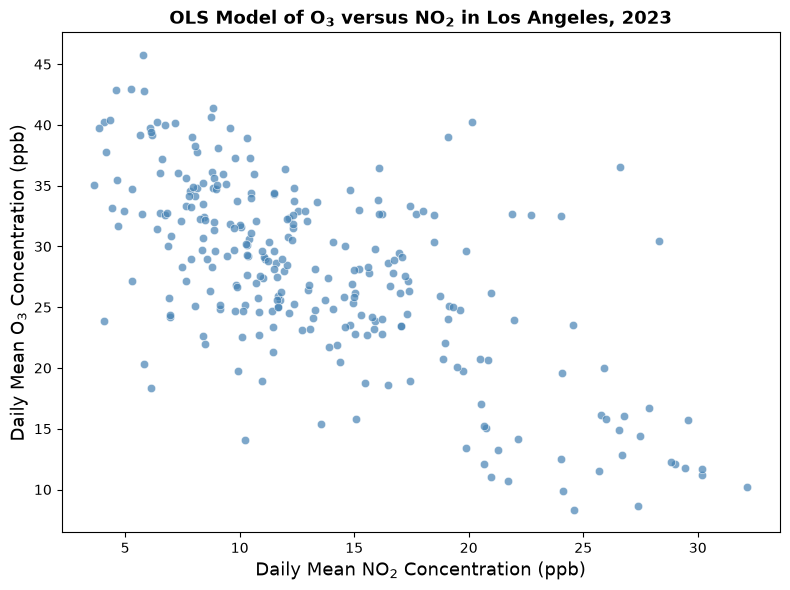

In [6]:
plt.figure(figsize=(8, 6))

sns.scatterplot(data=aqs, x="NO2_ppb", y="O3_ppb", color="steelblue", alpha=0.7)

plt.xlabel(r"Daily Mean $\mathrm{NO_2}$ Concentration (ppb)", fontsize=13)
plt.ylabel(r"Daily Mean $\mathrm{O_3}$ Concentration (ppb)", fontsize=13)
plt.title(r"OLS Model of $\mathbf{O_3}$ versus $\mathbf{NO_2}$ in Los Angeles, 2023", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [7]:
np.random.seed(13)

# Randomize row positions
random_indices = np.random.permutation(len(aqs))

# Use 20% for testing
number_test = int(np.ceil(0.20 * len(aqs)))

test_indices = random_indices[:number_test]
train_indices = random_indices[number_test:]

train_data = aqs.iloc[train_indices]
test_data = aqs.iloc[test_indices]

print("Training observations:", len(train_data))
print("Testing observations:", len(test_data))

Training observations: 218
Testing observations: 55


In [8]:
X_train = train_data[["NO2_ppb"]]
y_train = train_data["O3_ppb"]

X_test = test_data[["NO2_ppb"]]
y_test = test_data["O3_ppb"]

In [9]:
o3_model = lm.LinearRegression()

o3_model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[-0.83]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['NO2_ppb']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,38.9
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [10]:
o3_intercept = o3_model.intercept_
o3_slope = o3_model.coef_[0]

print(f"Intercept: {o3_intercept:.3f} ppb")
print(f"Slope: {o3_slope:.3f}")
print(
    f"Fitted equation: O3 = {o3_intercept:.3f} "
    f"{o3_slope:+.3f} × NO2"
)

Intercept: 38.899 ppb
Slope: -0.826
Fitted equation: O3 = 38.899 -0.826 × NO2


In [11]:
o3_predicted = o3_model.predict(X_test)

In [12]:
o3_residuals = y_test.to_numpy() - o3_predicted

o3_mae = np.mean(np.abs(o3_residuals))
o3_rmse = np.sqrt(np.mean(o3_residuals**2))
o3_r2 = o3_model.score(X_test, y_test)

print(f"Test MAE: {o3_mae:.2f} ppb")
print(f"Test RMSE: {o3_rmse:.2f} ppb")
print(f"Test R²: {o3_r2:.3f}")

Test MAE: 4.27 ppb
Test RMSE: 5.46 ppb
Test R²: 0.446


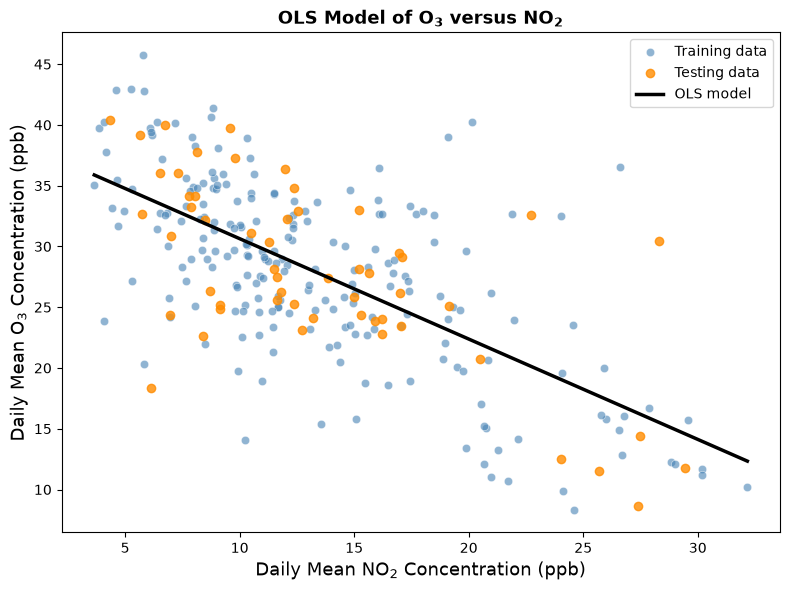

In [13]:
x_line = np.linspace(aqs["NO2_ppb"].min(), aqs["NO2_ppb"].max(), 200)

x_line_df = pd.DataFrame({"NO2_ppb": x_line})

y_line = o3_model.predict(x_line_df)

plt.figure(figsize=(8, 6))

sns.scatterplot(x=X_train["NO2_ppb"], y=y_train, color="steelblue", alpha=0.6, label="Training data")
plt.scatter(X_test["NO2_ppb"], y_test, color="darkorange", alpha=0.8, label="Testing data")
plt.plot(x_line, y_line, color="black", linewidth=2.5, label="OLS model")

plt.xlabel(r"Daily Mean $\mathrm{NO_2}$ Concentration (ppb)", fontsize=13)
plt.ylabel(r"Daily Mean $\mathrm{O_3}$ Concentration (ppb)", fontsize=13)
plt.title(r"OLS Model of $\mathbf{O_3}$ versus $\mathbf{NO_2}$", fontsize=13, fontweight="bold")
plt.legend()
plt.tight_layout()
plt.show()

3. The linear model performs moderately well. Its test R^2 of 0.446 means NO2 explains approximately 45% of the variation in the testing O3 concentrations. The model also captures the general negative relationship between the pollutants.

   However, approximately 55% of the test variation remains unexplained. O3 also depends on temperature, sunlight, wind, volatile organic compounds, atmospheric mixing, and other factors. The relationship may not be perfectly linear, so NO2 alone cannot produce highly accurate predictions.

## **Mauna Loa CO2**

In [14]:
co2 = pd.read_csv("../Data/ManuaLoa_CO2.csv")

print(co2.shape)
print(co2.head())
print(co2.tail())

(791, 8)
   year  month  decimal date  average  deseasonalized  ndays  sdev   unc
0  1958      3     1958.2027   315.70          314.43     -1 -9.99 -0.99
1  1958      4     1958.2877   317.45          315.16     -1 -9.99 -0.99
2  1958      5     1958.3699   317.51          314.71     -1 -9.99 -0.99
3  1958      6     1958.4548   317.24          315.14     -1 -9.99 -0.99
4  1958      7     1958.5370   315.86          315.18     -1 -9.99 -0.99
     year  month  decimal date  average  deseasonalized  ndays  sdev   unc
786  2023      9     2023.7083   418.51          421.96     18  0.30  0.14
787  2023     10     2023.7917   418.82          422.12     27  0.47  0.17
788  2023     11     2023.8750   420.46          422.43     21  0.91  0.38
789  2023     12     2023.9583   421.86          422.56     20  0.70  0.30
790  2024      1     2024.0417   422.80          422.53     27  0.60  0.22


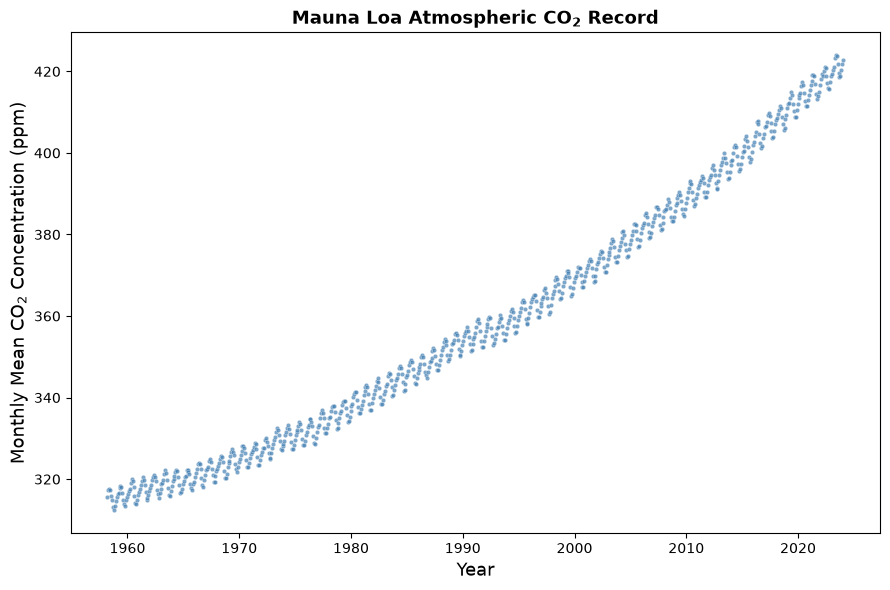

In [15]:
plt.figure(figsize=(9, 6))

sns.scatterplot(x=co2["decimal date"], y=co2["average"], alpha=0.7, s=10, color="steelblue")

plt.xlabel("Year", fontsize=13)
plt.ylabel(r"Monthly Mean CO$_2$ Concentration (ppm)", fontsize=13)
plt.title(r"Mauna Loa Atmospheric $\mathbf{CO_2}$ Record", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

In [16]:
co2_train = co2[co2["decimal date"] < 2000].copy()

co2_test = co2[co2["decimal date"] >= 2000].copy()

print("Training observations:", len(co2_train))
print("Testing observations:", len(co2_test))

Training observations: 502
Testing observations: 289


In [17]:
X_co2_train = co2_train[["decimal date"]]
y_co2_train = co2_train["average"]

X_co2_test = co2_test[["decimal date"]]
y_co2_test = co2_test["average"]

In [18]:
co2_model = lm.LinearRegression()

co2_model.fit(X_co2_train, y_co2_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[1.32]
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](1,)",['decimal date']
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,-2281
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)


In [19]:
co2_intercept = co2_model.intercept_
co2_slope = co2_model.coef_[0]

print(f"Intercept: {co2_intercept:.3f}")
print(f"Slope: {co2_slope:.3f} ppm per year")

print(
    f"Fitted equation: CO2 = {co2_intercept:.3f} "
    f"+ {co2_slope:.3f} × decimal year"
)

Intercept: -2280.591
Slope: 1.323 ppm per year
Fitted equation: CO2 = -2280.591 + 1.323 × decimal year


In [20]:
co2_predicted = co2_model.predict(X_co2_test)

In [21]:
co2_residuals = (y_co2_test.to_numpy() - co2_predicted)

co2_mae = np.mean(np.abs(co2_residuals))
co2_rmse = np.sqrt(np.mean(co2_residuals**2))
co2_r2 = co2_model.score(X_co2_test,y_co2_test)

print(f"Test MAE: {co2_mae:.2f} ppm")
print(f"Test RMSE: {co2_rmse:.2f} ppm")
print(f"Test R²: {co2_r2:.3f}")

Test MAE: 12.43 ppm
Test RMSE: 14.15 ppm
Test R²: 0.190


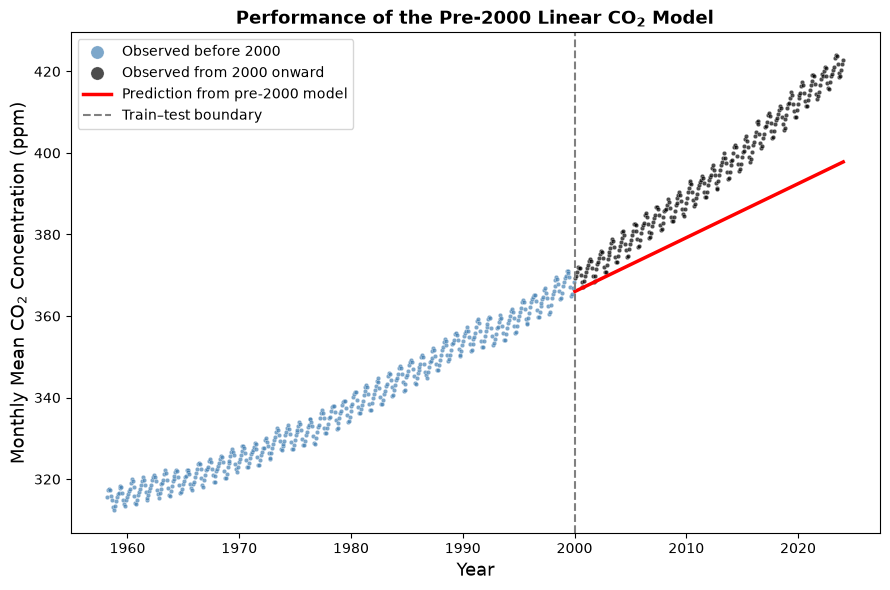

In [22]:
plt.figure(figsize=(9, 6))

sns.scatterplot(x=co2_train["decimal date"], y=y_co2_train, alpha=0.7, s=10, color="steelblue", label="Observed before 2000")
sns.scatterplot(x=co2_test["decimal date"], y=y_co2_test, alpha=0.7, s=10, color="black", label="Observed from 2000 onward")
plt.plot(co2_test["decimal date"], co2_predicted, color="red", linewidth=2.5, label="Prediction from pre-2000 model")
plt.axvline(2000, color="gray", linestyle="--", label="Train–test boundary")

plt.xlabel("Year", fontsize=13)
plt.ylabel(r"Monthly Mean CO$_2$ Concentration (ppm)", fontsize=13)
plt.title(r"Performance of the Pre-2000 Linear $\mathbf{CO_2}$ Model", fontsize=13, fontweight="bold")
plt.legend(markerscale=3)
plt.tight_layout()
plt.show()

2. The pre-2000 linear model does not predict post-2000 CO2 particularly well. Its test RMSE is approximately 14.15 ppm CO2, and its MAE is approximately 12.43 ppm CO2. The test R^2 is only 0.190.

   Near the beginning of 2024, the model predicts <400 ppm, whereas the observed concentration is approximately ~422 ppm. Therefore, the model underpredicts the final observation by approximately 25 ppm.

3. The linear model does not perform well for long-term prediction. Atmospheric CO2 is increasing at an accelerating rate, so the slope calculated from the earlier observations is too small for the later years. The linear model increasingly underpredicts CO2 as it projects farther beyond 2000.

   The model also cannot reproduce the seasonal CO2 cycle. A different model with seasonal variables would better represent both the accelerating trend and annual fluctuations.